In [ ]:
import numpy as np

# ---------------------------
# CONFIGURACIÓN DEL CIRCUITO
# ---------------------------

# Centro del arco
cx, cy = -300, -285
R = 170

# Puntos de inicio/fin en tu coordenada original
entry  = np.array([-354.66401, -445.97157])
exit_  = np.array([-138.12432, -336.92555])

# Número de líneas que quieres analizar
N = 300


# ---------------------------------------
# FUNCIONES DE GEOMETRÍA
# ---------------------------------------

def length(p1, p2):
    """Distancia entre dos puntos."""
    return np.linalg.norm(p2 - p1)

def angle_of_point(p, cx, cy):
    """Ángulo polar del punto relativo al centro."""
    x, y = p[0] - cx, p[1] - cy
    return np.arctan2(y, x)

def point_on_circle(theta, cx, cy, R):
    """Punto en el círculo dado un ángulo."""
    return np.array([cx + R*np.cos(theta),
                    cy + R*np.sin(theta)])


# ---------------------------------------
# GENERACIÓN DE LÍNEAS DE CARRERA
# ---------------------------------------

def racing_line(theta_entry, theta_exit):
    """
    Crea la línea:
    - recta desde entry → punto de tangencia 1
    - arco del círculo entre theta_entry y theta_exit
    - recta hasta exit
    """

    p1 = point_on_circle(theta_entry, cx, cy, R)
    p2 = point_on_circle(theta_exit, cx, cy, R)

    # Longitud de cada segmento
    L1 = length(entry, p1)
    Larc = R * abs(theta_exit - theta_entry)
    L2 = length(p2, exit_)

    return L1 + Larc + L2


# ---------------------------------------
# OPTIMIZACIÓN BÁSICA
# ---------------------------------------

θ_entry_real = angle_of_point(entry, cx, cy)
θ_exit_real  = angle_of_point(exit_, cx, cy)

# Probamos variaciones de ±20º
delta = np.linspace(-0.35, 0.35, N)

results = []

for d1 in delta:
    for d2 in delta:
        L = racing_line(θ_entry_real + d1, θ_exit_real + d2)
        results.append((L, d1, d2))

best = min(results, key=lambda x: x[0])

print("Mejor longitud:", best[0])
print("Desviación entrada:", best[1])
print("Desviación salida:", best[2])

Mejor longitud: 269.31279092904487
Desviación entrada: 0.35
Desviación salida: -0.35


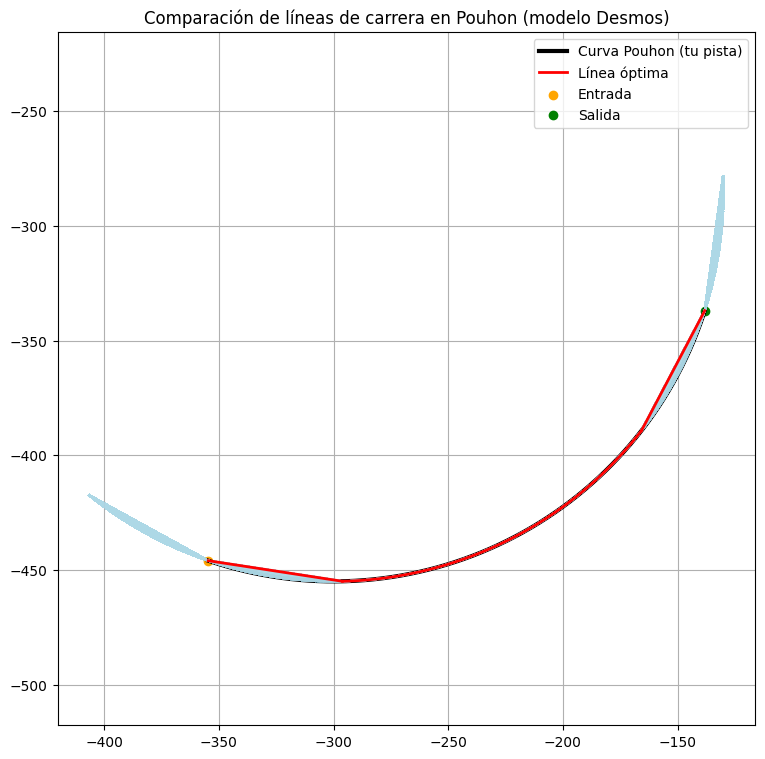

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------
# CONFIGURACIÓN DEL ARCO (Pouhon)
# ---------------------------

cx, cy = -300, -285   # centro del arco
R = 170               # radio

entry  = np.array([-354.66401, -445.97157])
exit_  = np.array([-138.12432, -336.92555])

# ---------------------------
# FUNCIONES
# ---------------------------

def length(p1, p2):
    return np.linalg.norm(p2 - p1)

def angle_of_point(p, cx, cy):
    x, y = p[0] - cx, p[1] - cy
    return np.arctan2(y, x)

def point_on_circle(theta, cx, cy, R):
    return np.array([cx + R*np.cos(theta), 
                     cy + R*np.sin(theta)])

def racing_line_points(theta_entry, theta_exit, resolution=200):
    p1 = point_on_circle(theta_entry, cx, cy, R)
    p2 = point_on_circle(theta_exit, cx, cy, R)

    line1 = np.linspace(entry, p1, 50)
    thetas = np.linspace(theta_entry, theta_exit, resolution)
    arc = np.array([point_on_circle(t, cx, cy, R) for t in thetas])
    line2 = np.linspace(p2, exit_, 50)

    return line1, arc, line2


# ---------------------------
# OPTIMIZACIÓN
# ---------------------------

θ_entry_real = angle_of_point(entry, cx, cy)
θ_exit_real  = angle_of_point(exit_, cx, cy)

def racing_line_length(te, tx):
    p1 = point_on_circle(te, cx, cy, R)
    p2 = point_on_circle(tx, cx, cy, R)
    return length(entry, p1) + R*abs(tx - te) + length(p2, exit_)


# variaciones ±20°
N = 100
delta = np.linspace(-0.35, 0.35, N)

results = []
all_lines = []

for d1 in delta:
    for d2 in delta:
        te = θ_entry_real + d1
        tx = θ_exit_real + d2

        L = racing_line_length(te, tx)
        results.append((L, te, tx))

        # guardamos la curva completa para graficarla luego
        all_lines.append(racing_line_points(te, tx))

# mejor línea
best = min(results, key=lambda x: x[0])
best_te, best_tx = best[1], best[2]


# ---------------------------
# GRAFICAR
# ---------------------------

plt.figure(figsize=[9,9])

# 1. PISTA = SOLO LA PARTE ENTRE ENTRY Y EXIT
theta_track = np.linspace(θ_entry_real, θ_exit_real, 400)
track = np.array([point_on_circle(t, cx, cy, R) for t in theta_track])
plt.plot(track[:,0], track[:,1], color='black', linewidth=3, label="Curva Pouhon (tu pista)")

# 2. TODAS LAS LÍNEAS DE CARRERA
for (line1, arc, line2) in all_lines:
    plt.plot(line1[:,0], line1[:,1], color='lightblue', alpha=0.15)
    plt.plot(arc[:,0], arc[:,1], color='lightblue', alpha=0.15)
    plt.plot(line2[:,0], line2[:,1], color='lightblue', alpha=0.15)

# 3. LA LÍNEA DE CARRERA ÓPTIMA
line1, arc, line2 = racing_line_points(best_te, best_tx)
plt.plot(line1[:,0], line1[:,1], color='red', linewidth=2, label="Línea óptima")
plt.plot(arc[:,0], arc[:,1], color='red', linewidth=2)
plt.plot(line2[:,0], line2[:,1], color='red', linewidth=2)

# puntos clave
plt.scatter(*entry, color='orange', label="Entrada")
plt.scatter(*exit_, color='green', label="Salida")

plt.axis('equal')
plt.grid(True)
plt.legend()
plt.title("Comparación de líneas de carrera en Pouhon (modelo Desmos)")
plt.show()


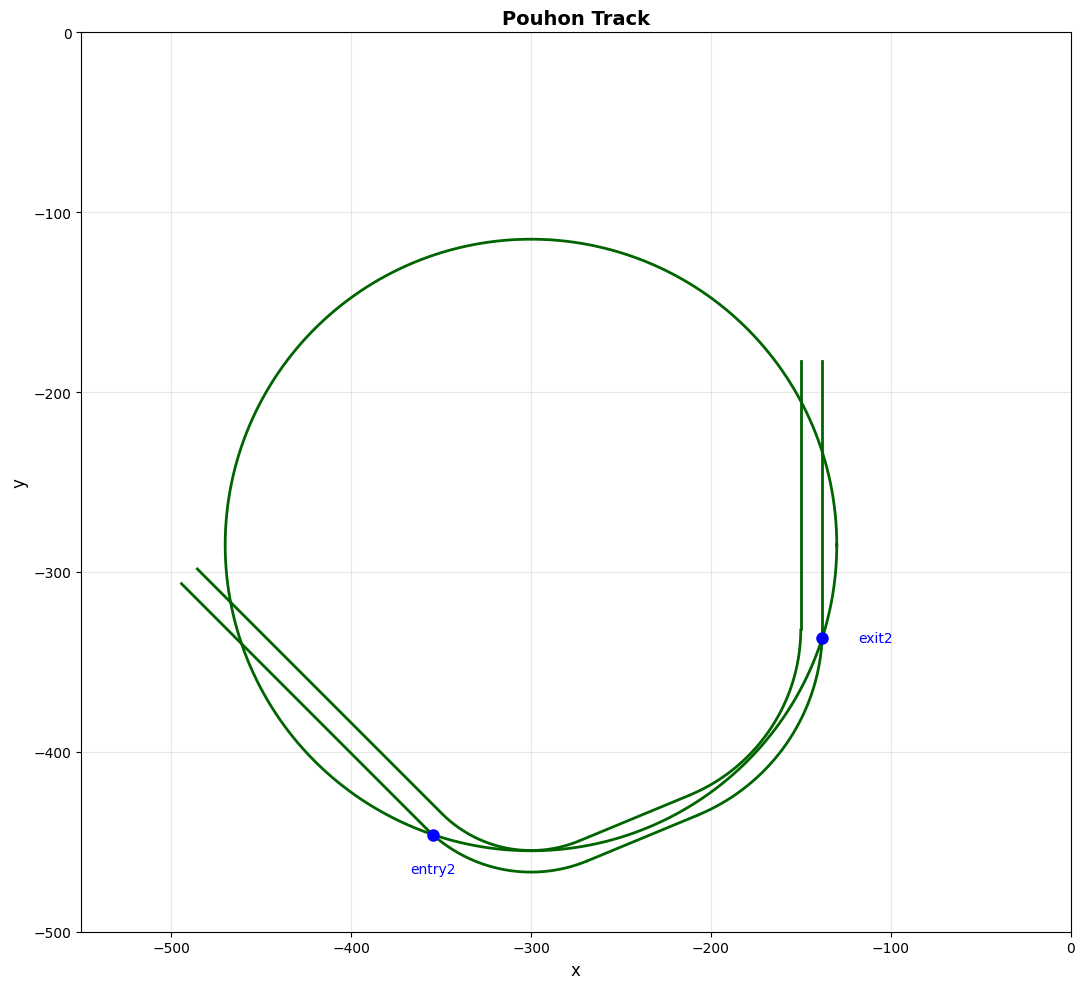

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Create figure and axis
fig, ax = plt.subplots(1, 1, figsize=(12, 10))

# Define the curves and lines from your Desmos graph

# Line 1: y = -x - 800.8 {y < x + 530 - 341.5} {y > x + 300 - 384.85}
x1 = np.linspace(-600, 200, 1000)
y1 = -x1 - 800.8
mask1 = (y1 < x1 + 188.5) & (y1 > x1 + 300 - 384.85)
ax.plot(x1[mask1], y1[mask1], 'darkgreen', linewidth=2)

# Line 2: y = -x - 800.8 + 12*sqrt(2) {y < x + 188.5} {y > x - 84.85}
y2 = -x1 - 800.8 + 12*np.sqrt(2)
mask2 = (y2 < x1 + 188.5) & (y2 > x1 - 84.85)
ax.plot(x1[mask2], y2[mask2], 'darkgreen', linewidth=2)

# Circle 1: (x + 300)^2 + (y + 384.85)^2 = 70^2 
# {y < x + 300 - 384.85} {y + 384.85 < -1/tan(22.5) * (x + 300)}
theta = np.linspace(0, 2*np.pi, 1000)
x_circ1 = -300 + 70*np.cos(theta)
y_circ1 = -384.85 + 70*np.sin(theta)
mask_circ1 = (y_circ1 < x_circ1 + 300 - 384.85) & (y_circ1 + 384.85 < -1/np.tan(np.radians(22.5)) * (x_circ1 + 300))
ax.plot(x_circ1[mask_circ1], y_circ1[mask_circ1], 'darkgreen', linewidth=2)

# Circle 2: (x + 300)^2 + (y + 384.85)^2 = 82^2
# {y < x + 300 - 384.85} {y + 384.85 < -1/tan(22.5) * (x + 300)}
x_circ2 = -300 + 82*np.cos(theta)
y_circ2 = -384.85 + 82*np.sin(theta)
mask_circ2 = (y_circ2 < x_circ2 + 300 - 384.85) & (y_circ2 + 384.85 < -1/np.tan(np.radians(22.5)) * (x_circ2 + 300))
ax.plot(x_circ2[mask_circ2], y_circ2[mask_circ2], 'darkgreen', linewidth=2)

# Tangent line 1: y = tan(22.5)*x - 336.35 
# {y + 331.65 < -1/tan(22.5) * (x + 250)} {y + 384.85 > -1/tan(22.5) * (x + 300)}
x_tan = np.linspace(-600, 200, 1000)
y_tan1 = np.tan(np.radians(22.5))*x_tan - 336.35
mask_tan1 = (y_tan1 + 331.65 < -1/np.tan(np.radians(22.5)) * (x_tan + 250)) & \
            (y_tan1 + 384.85 > -1/np.tan(np.radians(22.5)) * (x_tan + 300))
ax.plot(x_tan[mask_tan1], y_tan1[mask_tan1], 'darkgreen', linewidth=2)

# Tangent line 2: y = tan(22.5)*x - 336.35 - 12/cos(22.5) 
# {y + 331.65 < -1/tan(22.5) * (x + 250)} {y + 384.85 > -1/tan(22.5) * (x + 300)}
y_tan2 = np.tan(np.radians(22.5))*x_tan - 336.35 - 12/np.cos(np.radians(22.5))
mask_tan2 = (y_tan2 + 331.65 < -1/np.tan(np.radians(22.5)) * (x_tan + 250)) & \
            (y_tan2 + 384.85 > -1/np.tan(np.radians(22.5)) * (x_tan + 300))
ax.plot(x_tan[mask_tan2], y_tan2[mask_tan2], 'darkgreen', linewidth=2)

# Circle 3: (x + 250)^2 + (y + 331.65)^2 = 100^2 
# {y < -331.65} {y + 331.65 > -1/tan(22.5) * (x + 250)}
x_circ3 = -250 + 100*np.cos(theta)
y_circ3 = -331.65 + 100*np.sin(theta)
mask_circ3 = (y_circ3 < -331.65) & (y_circ3 + 331.65 > -1/np.tan(np.radians(22.5)) * (x_circ3 + 250))
ax.plot(x_circ3[mask_circ3], y_circ3[mask_circ3], 'darkgreen', linewidth=2)

# Circle 4: (x + 250)^2 + (y + 331.65)^2 = 112^2 
# {y < -331.65} {y + 331.65 > -1/tan(22.5) * (x + 250)}
x_circ4 = -250 + 112*np.cos(theta)
y_circ4 = -331.65 + 112*np.sin(theta)
mask_circ4 = (y_circ4 < -331.65) & (y_circ4 + 331.65 > -1/np.tan(np.radians(22.5)) * (x_circ4 + 250))
ax.plot(x_circ4[mask_circ4], y_circ4[mask_circ4], 'darkgreen', linewidth=2)

# Vertical lines
y_vert = np.linspace(-500, -150, 1000)
# x = -150 {-182.62 > y > -331.65}
mask_v1 = (y_vert > -331.65) & (y_vert < -182.62)
ax.plot(np.full_like(y_vert[mask_v1], -150), y_vert[mask_v1], 'darkgreen', linewidth=2)
# x = -138 {-182.62 > y > -331.65}
mask_v2 = (y_vert > -331.65) & (y_vert < -182.62)
ax.plot(np.full_like(y_vert[mask_v2], -138), y_vert[mask_v2], 'darkgreen', linewidth=2)

# Large circle: (x + 300)^2 + (y + 285)^2 = 170^2
x_circ_large = -300 + 170*np.cos(theta)
y_circ_large = -285 + 170*np.sin(theta)
ax.plot(x_circ_large, y_circ_large, 'darkgreen', linewidth=2)

# Add labeled points
ax.plot(-354.66401, -445.97157, 'bo', markersize=8)
ax.text(-354.66401, -445.97157 - 15, 'entry2', fontsize=10, ha='center', va='top', color='blue')

ax.plot(-138.12432, -336.92555, 'bo', markersize=8)
ax.text(-138.12432 + 20, -336.92555, 'exit2', fontsize=10, ha='left', va='center', color='blue')

# Set equal aspect ratio and grid
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.set_xlim(-550, 0)
ax.set_ylim(-500, 0)
ax.set_xlabel('x', fontsize=12)
ax.set_ylabel('y', fontsize=12)
ax.set_title('Pouhon Track', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

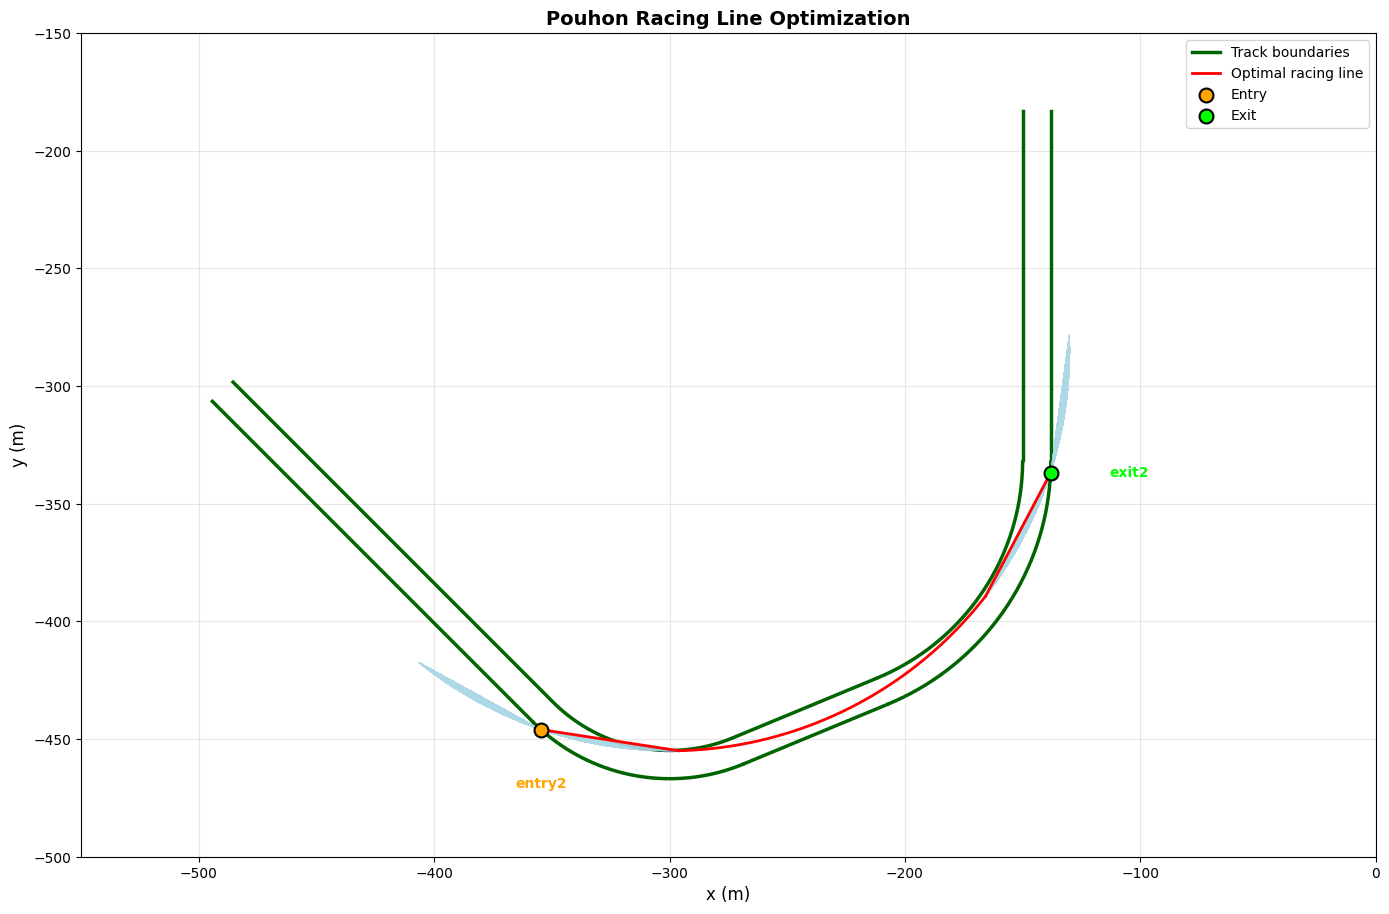


Optimal racing line:
  Entry angle: -88.70°
  Exit angle: -37.84°
  Total length: 269.31m


In [16]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------
# RACING LINE FUNCTIONS
# ---------------------------

cx, cy = -300, -285   # centro del arco
R = 170               # radio

entry  = np.array([-354.66401, -445.97157])
exit_  = np.array([-138.12432, -336.92555])

def length(p1, p2):
    return np.linalg.norm(p2 - p1)

def angle_of_point(p, cx, cy):
    x, y = p[0] - cx, p[1] - cy
    return np.arctan2(y, x)

def point_on_circle(theta, cx, cy, R):
    return np.array([cx + R*np.cos(theta), 
                     cy + R*np.sin(theta)])

def racing_line_points(theta_entry, theta_exit, resolution=200):
    p1 = point_on_circle(theta_entry, cx, cy, R)
    p2 = point_on_circle(theta_exit, cx, cy, R)

    line1 = np.linspace(entry, p1, 50)
    thetas = np.linspace(theta_entry, theta_exit, resolution)
    arc = np.array([point_on_circle(t, cx, cy, R) for t in thetas])
    line2 = np.linspace(p2, exit_, 50)

    return line1, arc, line2

def racing_line_length(te, tx):
    p1 = point_on_circle(te, cx, cy, R)
    p2 = point_on_circle(tx, cx, cy, R)
    return length(entry, p1) + R*abs(tx - te) + length(p2, exit_)

# ---------------------------
# OPTIMIZATION
# ---------------------------

θ_entry_real = angle_of_point(entry, cx, cy)
θ_exit_real  = angle_of_point(exit_, cx, cy)

N = 100
delta = np.linspace(-0.35, 0.35, N)

results = []
all_lines = []

for d1 in delta:
    for d2 in delta:
        te = θ_entry_real + d1
        tx = θ_exit_real + d2

        L = racing_line_length(te, tx)
        results.append((L, te, tx))
        all_lines.append(racing_line_points(te, tx))

best = min(results, key=lambda x: x[0])
best_te, best_tx = best[1], best[2]

# ---------------------------
# PLOTTING
# ---------------------------

fig, ax = plt.subplots(1, 1, figsize=(14, 10))

# TRACK BOUNDARIES FROM DESMOS

x1 = np.linspace(-600, 200, 1000)
y1 = -x1 - 800.8
mask1 = (y1 < x1 + 188.5) & (y1 > x1 + 300 - 384.85)
ax.plot(x1[mask1], y1[mask1], 'darkgreen', linewidth=2.5, label='Track boundaries')

y2 = -x1 - 800.8 + 12*np.sqrt(2)
mask2 = (y2 < x1 + 188.5) & (y2 > x1 - 84.85)
ax.plot(x1[mask2], y2[mask2], 'darkgreen', linewidth=2.5)

theta = np.linspace(0, 2*np.pi, 1000)
x_circ1 = -300 + 70*np.cos(theta)
y_circ1 = -384.85 + 70*np.sin(theta)
mask_circ1 = (y_circ1 < x_circ1 + 300 - 384.85) & (y_circ1 + 384.85 < -1/np.tan(np.radians(22.5)) * (x_circ1 + 300))
ax.plot(x_circ1[mask_circ1], y_circ1[mask_circ1], 'darkgreen', linewidth=2.5)

x_circ2 = -300 + 82*np.cos(theta)
y_circ2 = -384.85 + 82*np.sin(theta)
mask_circ2 = (y_circ2 < x_circ2 + 300 - 384.85) & (y_circ2 + 384.85 < -1/np.tan(np.radians(22.5)) * (x_circ2 + 300))
ax.plot(x_circ2[mask_circ2], y_circ2[mask_circ2], 'darkgreen', linewidth=2.5)

x_tan = np.linspace(-600, 200, 1000)
y_tan1 = np.tan(np.radians(22.5))*x_tan - 336.35
mask_tan1 = (y_tan1 + 331.65 < -1/np.tan(np.radians(22.5)) * (x_tan + 250)) & \
            (y_tan1 + 384.85 > -1/np.tan(np.radians(22.5)) * (x_tan + 300))
ax.plot(x_tan[mask_tan1], y_tan1[mask_tan1], 'darkgreen', linewidth=2.5)

y_tan2 = np.tan(np.radians(22.5))*x_tan - 336.35 - 12/np.cos(np.radians(22.5))
mask_tan2 = (y_tan2 + 331.65 < -1/np.tan(np.radians(22.5)) * (x_tan + 250)) & \
            (y_tan2 + 384.85 > -1/np.tan(np.radians(22.5)) * (x_tan + 300))
ax.plot(x_tan[mask_tan2], y_tan2[mask_tan2], 'darkgreen', linewidth=2.5)

x_circ3 = -250 + 100*np.cos(theta)
y_circ3 = -331.65 + 100*np.sin(theta)
mask_circ3 = (y_circ3 < -331.65) & (y_circ3 + 331.65 > -1/np.tan(np.radians(22.5)) * (x_circ3 + 250))
ax.plot(x_circ3[mask_circ3], y_circ3[mask_circ3], 'darkgreen', linewidth=2.5)

x_circ4 = -250 + 112*np.cos(theta)
y_circ4 = -331.65 + 112*np.sin(theta)
mask_circ4 = (y_circ4 < -331.65) & (y_circ4 + 331.65 > -1/np.tan(np.radians(22.5)) * (x_circ4 + 250))
ax.plot(x_circ4[mask_circ4], y_circ4[mask_circ4], 'darkgreen', linewidth=2.5)

y_vert = np.linspace(-500, -150, 1000)
mask_v1 = (y_vert > -331.65) & (y_vert < -182.62)
ax.plot(np.full_like(y_vert[mask_v1], -150), y_vert[mask_v1], 'darkgreen', linewidth=2.5)
mask_v2 = (y_vert > -331.65) & (y_vert < -182.62)
ax.plot(np.full_like(y_vert[mask_v2], -138), y_vert[mask_v2], 'darkgreen', linewidth=2.5)

# x_circ_large = -300 + 170*np.cos(theta)
# y_circ_large = -285 + 170*np.sin(theta)
# ax.plot(x_circ_large, y_circ_large, 'darkgreen', linewidth=2.5)

# ALL RACING LINES (LIGHT BLUE)
for (line1, arc, line2) in all_lines:
    ax.plot(line1[:,0], line1[:,1], color='lightblue', alpha=0.1, linewidth=0.5)
    ax.plot(arc[:,0], arc[:,1], color='lightblue', alpha=0.1, linewidth=0.5)
    ax.plot(line2[:,0], line2[:,1], color='lightblue', alpha=0.1, linewidth=0.5)

# OPTIMAL RACING LINE (RED)
line1, arc, line2 = racing_line_points(best_te, best_tx)
ax.plot(line1[:,0], line1[:,1], color='red', linewidth=2, label='Optimal racing line', zorder=10)
ax.plot(arc[:,0], arc[:,1], color='red', linewidth=2, zorder=10)
ax.plot(line2[:,0], line2[:,1], color='red', linewidth=2, zorder=10)

# KEY POINTS
ax.scatter(*entry, color='orange', s=100, label='Entry', zorder=15, edgecolors='black', linewidths=1.5)
ax.scatter(*exit_, color='lime', s=100, label='Exit', zorder=15, edgecolors='black', linewidths=1.5)

ax.text(entry[0], entry[1] - 20, 'entry2', fontsize=10, ha='center', va='top', color='orange', fontweight='bold')
ax.text(exit_[0] + 25, exit_[1], 'exit2', fontsize=10, ha='left', va='center', color='lime', fontweight='bold')

# FORMATTING
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.set_xlim(-550, 0)
ax.set_ylim(-500, -150)
ax.set_xlabel('x (m)', fontsize=12)
ax.set_ylabel('y (m)', fontsize=12)
ax.set_title('Pouhon Racing Line Optimization', fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=10)

plt.tight_layout()
plt.show()

print(f"\nOptimal racing line:")
print(f"  Entry angle: {np.degrees(best_te):.2f}°")
print(f"  Exit angle: {np.degrees(best_tx):.2f}°")
print(f"  Total length: {best[0]:.2f}m")

In [1]:
import numpy as np

# The key fix: for each candidate line, fit a NEW circle through
# entry point, apex, and exit point — giving a unique radius per trajectory.

def circle_from_3_points(p1, p2, p3):
    """Returns (cx, cy, r) of circle passing through 3 points."""
    ax, ay = p1
    bx, by = p2
    cx_, cy_ = p3
    
    D = 2 * (ax*(by - cy_) + bx*(cy_ - ay) + cx_*(ay - by))
    if abs(D) < 1e-10:
        return None  # collinear points
    
    ux = ((ax**2 + ay**2)*(by - cy_) + (bx**2 + by**2)*(cy_ - ay) + (cx_**2 + cy_**2)*(ay - by)) / D
    uy = ((ax**2 + ay**2)*(cx_ - bx) + (bx**2 + by**2)*(ax - cx_) + (cx_**2 + cy_**2)*(bx - ax)) / D
    
    r = np.sqrt((ax - ux)**2 + (ay - uy)**2)
    return ux, uy, r

def compute_time(p1, apex, p2, mu=1.8, g=9.81):
    """Given entry, apex, exit points — compute transit time."""
    result = circle_from_3_points(p1, apex, p2)
    if result is None:
        return None, None
    
    cx_, cy_, r = result
    
    # Arc length via angle subtended
    def angle(p):
        return np.arctan2(p[1] - cy_, p[0] - cx_)
    
    t1, t2 = angle(p1), angle(p2)
    delta_theta = abs(t2 - t1)
    if delta_theta > np.pi:
        delta_theta = 2*np.pi - delta_theta
    
    arc_length = r * delta_theta
    v_max = np.sqrt(mu * g * r)
    time = arc_length / v_max
    
    return time, r

# Example: vary the apex position along the track width
# You define a set of candidate apex points between inner and outer track edge
# then find which one minimizes time

entry = np.array([-354.66401, -445.97157])
exit_ = np.array([-138.12432, -336.92555])

# Apex candidates: interpolate between inner apex and outer apex
# (you define these from your Desmos track model)
inner_apex = np.array([-300, -455])  # tightest point, small r → slow
outer_apex = np.array([-300, -370])  # widest point, large r → fast but long

N = 200
results = []
for t in np.linspace(0, 1, N):
    apex = inner_apex * (1 - t) + outer_apex * t
    time, r = compute_time(entry, apex, exit_)
    if time is not None:
        results.append((time, r, apex, t))

best = min(results, key=lambda x: x[0])
print(f"Best apex parameter t = {best[3]:.3f}")
print(f"Radius: {best[1]:.1f} m")
print(f"Time: {best[0]:.3f} s")
print(f"Apex point: {best[2]}")

# Show tradeoff
print("\nTime vs radius tradeoff (showing every 20th point):")
print(f"{'t':>6} {'radius(m)':>10} {'time(s)':>10}")
for i, (time, r, apex, t) in enumerate(results):
    if i % 20 == 0:
        print(f"{t:>6.2f} {r:>10.1f} {time:>10.4f}")

Best apex parameter t = 0.432
Radius: 35057.0 m
Time: 0.308 s
Apex point: [-300.         -418.26633166]

Time vs radius tradeoff (showing every 20th point):
     t  radius(m)    time(s)
  0.00      170.0     4.9265
  0.10      213.5     4.1990
  0.20      303.1     3.4093
  0.30      545.5     2.4910
  0.40     2574.5     1.1375
  0.50     1042.4     1.7910
  0.60      460.7     2.7201
  0.70      309.2     3.3719
  0.80      240.6     3.8985
  0.90      202.0     4.3533


Total valid trajectories: 7126
                           BASELINE       BEST      WORST
              t1 (apex1)       0.53       0.26       1.00
          tc (connector)       0.53       0.95       0.11
              t2 (apex2)       0.53       0.00       0.95
            Radius 1 (m)     103.83     381.39      56.52
            Radius 2 (m)     154.65     216.66     126.50
               v1 (km/h)     154.15     295.43     113.73
               v2 (km/h)     188.13     222.67     170.14
         Arc 1 angle (°)      45.58      12.25      89.91
         Arc 2 angle (°)      72.16      50.78      89.80
   Kink at connector (°)      26.60      43.50       7.88
          Total time (s)       5.66       4.10       7.00
       Score (penalised)       5.79       4.32       7.04
Time saved vs worst:    2.9044 s
Time saved vs baseline: 1.5580 s


FileNotFoundError: [Errno 2] No such file or directory: '/mnt/user-data/outputs/pouhon_v3.png'

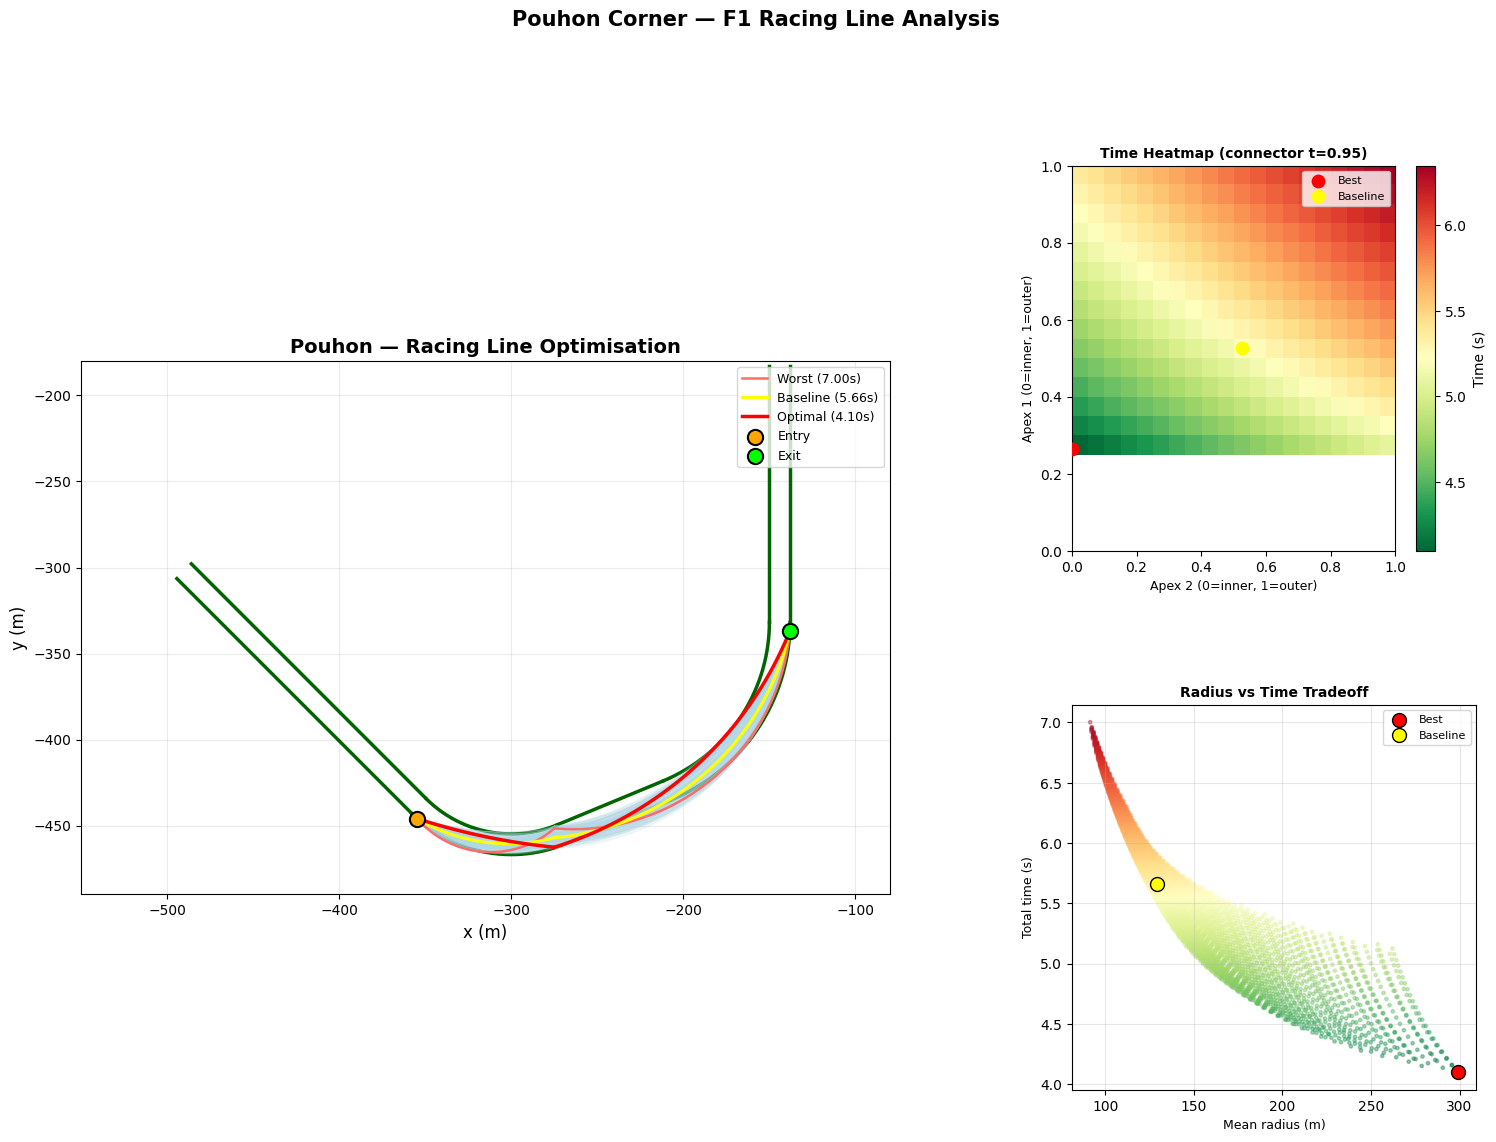

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# ─────────────────────────────────────────
# CONSTANTS & TRACK GEOMETRY
# ─────────────────────────────────────────
MU, G = 1.8, 9.81
R_MAX = 400  # physical cap on radius
SMOOTHNESS_WEIGHT = 0.9  # penalty weight for direction change at connector

entry = np.array([-354.66401, -445.97157])
exit_ = np.array([-138.12432, -336.92555])

apex1_inner = np.array([-313.65, -453.51])
apex1_outer = np.array([-315.99, -465.28])
apex2_inner = np.array([-166.84, -387.19])
apex2_outer = np.array([-156.86, -393.85])

slope   = np.tan(np.radians(22.5))
c_inner = -336.35
c_outer = -(336.35 + 12/np.cos(np.radians(22.5)))

def connector_point(t):
    c = c_inner*(1-t) + c_outer*t
    return np.array([-275.0, slope*-275.0 + c])

# ─────────────────────────────────────────
# MATH
# ─────────────────────────────────────────
def circle_from_3_points(p1, p2, p3):
    ax_, ay_ = p1; bx, by = p2; cx_, cy_ = p3
    D = 2*(ax_*(by-cy_) + bx*(cy_-ay_) + cx_*(ay_-by))
    if abs(D) < 1e-8: return None
    ux = ((ax_**2+ay_**2)*(by-cy_)+(bx**2+by**2)*(cy_-ay_)+(cx_**2+cy_**2)*(ay_-by))/D
    uy = ((ax_**2+ay_**2)*(cx_-bx)+(bx**2+by**2)*(ax_-cx_)+(cx_**2+cy_**2)*(bx-ax_))/D
    r  = np.sqrt((ax_-ux)**2+(ay_-uy)**2)
    return ux, uy, r

def tangent_direction(p1, p_mid, p2, at_end=True):
    """Unit tangent vector of the arc at entry (at_end=False) or exit (at_end=True)."""
    res = circle_from_3_points(p1, p_mid, p2)
    if res is None: return None
    cx_, cy_, r = res
    # tangent at a point on circle is perpendicular to radius
    pt = p2 if at_end else p1
    radial = pt - np.array([cx_, cy_])
    tangent = np.array([-radial[1], radial[0]])  # 90° CCW rotation
    # determine sign: should point in direction of travel
    travel = p2 - p1
    if np.dot(tangent, travel) < 0:
        tangent = -tangent
    return tangent / np.linalg.norm(tangent)

def kink_angle(p1, conn, apex2, exit_pt):
    """Angle (degrees) between exit tangent of arc1 and entry tangent of arc2 at connector."""
    t_out = tangent_direction(p1,   conn,   conn,   at_end=True)   # not meaningful alone
    # Better: use vectors from apex1→conn and conn→apex2
    v1 = conn   - p1
    v2 = exit_pt - conn
    # normalize
    v1 = v1 / np.linalg.norm(v1)
    v2 = v2 / np.linalg.norm(v2)
    cos_a = np.clip(np.dot(v1, v2), -1, 1)
    return np.degrees(np.arccos(cos_a))

def compute_arc(p1, p_mid, p2):
    res = circle_from_3_points(p1, p_mid, p2)
    if res is None: return None
    cx_, cy_, r = res
    if r > R_MAX: return None   # unphysical
    t1 = np.arctan2(p1[1]-cy_, p1[0]-cx_)
    t2 = np.arctan2(p2[1]-cy_, p2[0]-cx_)
    dt = (t2-t1+np.pi)%(2*np.pi)-np.pi
    arc = r*abs(dt)
    v   = np.sqrt(MU*G*r)
    return arc/v, r, arc, abs(np.degrees(dt))

def arc_points(p1, p_mid, p2, n=300):
    res = circle_from_3_points(p1, p_mid, p2)
    if res is None: return None
    cx_, cy_, r = res
    if r > R_MAX: return None
    t1 = np.arctan2(p1[1]-cy_, p1[0]-cx_)
    t2 = np.arctan2(p2[1]-cy_, p2[0]-cx_)
    dt = (t2-t1+np.pi)%(2*np.pi)-np.pi
    angs = np.linspace(t1, t1+dt, n)
    return cx_+r*np.cos(angs), cy_+r*np.sin(angs)

# ─────────────────────────────────────────
# OPTIMIZATION
# ─────────────────────────────────────────
N = 20
t_vals = np.linspace(0, 1, N)

results = []
for t1 in t_vals:
    apex1 = apex1_inner*(1-t1) + apex1_outer*t1
    for tc in t_vals:
        conn  = connector_point(tc)
        for t2 in t_vals:
            apex2 = apex2_inner*(1-t2) + apex2_outer*t2

            a1 = compute_arc(entry, apex1, conn)
            a2 = compute_arc(conn,  apex2, exit_)
            if a1 is None or a2 is None: continue

            time1, r1, l1, deg1 = a1
            time2, r2, l2, deg2 = a2

            # Penalise kink at connector: angle between incoming and outgoing directions
            v_in  = conn  - apex1
            v_out = apex2 - conn
            v_in  /= np.linalg.norm(v_in)
            v_out /= np.linalg.norm(v_out)
            kink_deg = np.degrees(np.arccos(np.clip(np.dot(v_in, v_out), -1, 1)))

            # Reject lines where either arc subtends > 90°
            if deg1 > 90 or deg2 > 90:
                continue

            # Smoothness penalty: adds fraction of a second per degree of kink
            penalty = SMOOTHNESS_WEIGHT * (kink_deg / 180.0)
            score   = time1 + time2 + penalty

            results.append(dict(
                t1=t1, tc=tc, t2=t2,
                apex1=apex1.copy(), conn=conn.copy(), apex2=apex2.copy(),
                time=time1+time2, score=score,
                r1=r1, r2=r2, l1=l1, l2=l2,
                v1=np.sqrt(MU*G*r1), v2=np.sqrt(MU*G*r2),
                kink=kink_deg, deg1=deg1, deg2=deg2
            ))

results.sort(key=lambda x: x['score'])
best  = results[0]
worst = results[-1]
baseline = min(results, key=lambda r: (r['t1']-0.5)**2+(r['tc']-0.5)**2+(r['t2']-0.5)**2)

print(f"Total valid trajectories: {len(results)}")
print("="*65)
print(f"{'':>24} {'BASELINE':>10} {'BEST':>10} {'WORST':>10}")
print("="*65)
rows = [('t1 (apex1)','t1'),('tc (connector)','tc'),('t2 (apex2)','t2'),
        ('Radius 1 (m)','r1'),('Radius 2 (m)','r2'),
        ('v1 (km/h)','v1kph'),('v2 (km/h)','v2kph'),
        ('Arc 1 angle (°)','deg1'),('Arc 2 angle (°)','deg2'),
        ('Kink at connector (°)','kink'),
        ('Total time (s)','time'),('Score (penalised)','score')]
for label, key in rows:
    def val(r):
        if key=='v1kph': return r['v1']*3.6
        if key=='v2kph': return r['v2']*3.6
        return r[key]
    fmt = '.2f' if key in ('t1','tc','t2') else '.2f'
    print(f"{label:>24} {val(baseline):>10.2f} {val(best):>10.2f} {val(worst):>10.2f}")
print("="*65)
print(f"Time saved vs worst:    {worst['time']-best['time']:.4f} s")
print(f"Time saved vs baseline: {baseline['time']-best['time']:.4f} s")

# ─────────────────────────────────────────
# PLOTTING
# ─────────────────────────────────────────
def draw_track(ax):
    theta = np.linspace(0, 2*np.pi, 2000)
    cot   = 1/np.tan(np.radians(22.5))
    x1    = np.linspace(-600, 200, 2000)

    y=-x1-800.8;             m=(y<x1+188.5)&(y>x1+300-384.85);  ax.plot(x1[m],y[m],'darkgreen',lw=2.5)
    y=-x1-800.8+12*np.sqrt(2);m=(y<x1+188.5)&(y>x1-84.85);      ax.plot(x1[m],y[m],'darkgreen',lw=2.5)
    xc=-300+70*np.cos(theta);yc=-384.85+70*np.sin(theta)
    m=(yc<xc+300-384.85)&(yc+384.85<-cot*(xc+300));              ax.plot(xc[m],yc[m],'darkgreen',lw=2.5)
    xc=-300+82*np.cos(theta);yc=-384.85+82*np.sin(theta)
    m=(yc<xc+300-384.85)&(yc+384.85<-cot*(xc+300));              ax.plot(xc[m],yc[m],'darkgreen',lw=2.5)
    xt=np.linspace(-600,200,2000)
    yt=slope*xt-336.35;       m=(yt+331.65<-cot*(xt+250))&(yt+384.85>-cot*(xt+300)); ax.plot(xt[m],yt[m],'darkgreen',lw=2.5)
    yt=slope*xt-336.35-12/np.cos(np.radians(22.5))
    m=(yt+331.65<-cot*(xt+250))&(yt+384.85>-cot*(xt+300));       ax.plot(xt[m],yt[m],'darkgreen',lw=2.5)
    xc=-250+100*np.cos(theta);yc=-331.65+100*np.sin(theta)
    m=(yc<-331.65)&(yc+331.65>-cot*(xc+250));                    ax.plot(xc[m],yc[m],'darkgreen',lw=2.5)
    xc=-250+112*np.cos(theta);yc=-331.65+112*np.sin(theta)
    m=(yc<-331.65)&(yc+331.65>-cot*(xc+250));                    ax.plot(xc[m],yc[m],'darkgreen',lw=2.5)
    yv=np.linspace(-500,-150,1000);mv=(yv>-331.65)&(yv<-182.62)
    ax.plot(np.full_like(yv[mv],-150),yv[mv],'darkgreen',lw=2.5)
    ax.plot(np.full_like(yv[mv],-138),yv[mv],'darkgreen',lw=2.5)

fig = plt.figure(figsize=(18,12))
gs  = GridSpec(2,2,figure=fig,width_ratios=[2,1],hspace=0.4,wspace=0.3)
ax_track    = fig.add_subplot(gs[:,0])
ax_time     = fig.add_subplot(gs[0,1])
ax_tradeoff = fig.add_subplot(gs[1,1])

draw_track(ax_track)

step = max(1, len(results)//400)
for res in results[::step]:
    p1=arc_points(entry,      res['apex1'], res['conn'])
    p2=arc_points(res['conn'], res['apex2'], exit_)
    if p1 and p2:
        ax_track.plot(p1[0],p1[1],color='lightblue',alpha=0.12,lw=0.5)
        ax_track.plot(p2[0],p2[1],color='lightblue',alpha=0.12,lw=0.5)

for res,col,lw,lab,zo in [(worst,'#ff6b6b',1.8,'Worst',8),(baseline,'yellow',2.2,'Baseline',9),(best,'red',2.5,'Optimal',10)]:
    p1=arc_points(entry,      res['apex1'],res['conn'])
    p2=arc_points(res['conn'], res['apex2'],exit_)
    if p1 and p2:
        ax_track.plot(p1[0],p1[1],color=col,lw=lw,label=f"{lab} ({res['time']:.2f}s)",zorder=zo)
        ax_track.plot(p2[0],p2[1],color=col,lw=lw,zorder=zo)

ax_track.scatter(*entry,color='orange',s=120,zorder=15,edgecolors='black',lw=1.5,label='Entry')
ax_track.scatter(*exit_, color='lime',  s=120,zorder=15,edgecolors='black',lw=1.5,label='Exit')
ax_track.set_aspect('equal'); ax_track.set_xlim(-550,-80); ax_track.set_ylim(-490,-180)
ax_track.grid(True,alpha=0.25); ax_track.set_xlabel('x (m)',fontsize=12); ax_track.set_ylabel('y (m)',fontsize=12)
ax_track.set_title('Pouhon — Racing Line Optimisation',fontsize=14,fontweight='bold')
ax_track.legend(loc='upper right',fontsize=9)

# Heatmap
tc_best = best['tc']
grid = np.full((N,N),np.nan)
for res in results:
    if abs(res['tc']-tc_best)<1e-9:
        i=np.argmin(np.abs(t_vals-res['t1']))
        j=np.argmin(np.abs(t_vals-res['t2']))
        grid[i,j]=res['time']
im=ax_time.imshow(grid,origin='lower',aspect='auto',extent=[0,1,0,1],cmap='RdYlGn_r')
plt.colorbar(im,ax=ax_time,label='Time (s)')
ax_time.set_xlabel('Apex 2 (0=inner, 1=outer)',fontsize=9)
ax_time.set_ylabel('Apex 1 (0=inner, 1=outer)',fontsize=9)
ax_time.set_title(f'Time Heatmap (connector t={tc_best:.2f})',fontsize=10,fontweight='bold')
ax_time.scatter(best['t2'],best['t1'],color='red',s=80,zorder=5,label='Best')
ax_time.scatter(baseline['t2'],baseline['t1'],color='yellow',s=80,zorder=5,label='Baseline')
ax_time.legend(fontsize=8)

# Tradeoff
r_avg=np.array([(r['r1']+r['r2'])/2 for r in results])
t_arr=np.array([r['time'] for r in results])
ax_tradeoff.scatter(r_avg,t_arr,c=t_arr,cmap='RdYlGn_r',s=6,alpha=0.4)
ax_tradeoff.scatter((best['r1']+best['r2'])/2,    best['time'],    color='red',   s=100,zorder=5,edgecolors='black',label='Best')
ax_tradeoff.scatter((baseline['r1']+baseline['r2'])/2,baseline['time'],color='yellow',s=100,zorder=5,edgecolors='black',label='Baseline')
ax_tradeoff.set_xlabel('Mean radius (m)',fontsize=9); ax_tradeoff.set_ylabel('Total time (s)',fontsize=9)
ax_tradeoff.set_title('Radius vs Time Tradeoff',fontsize=10,fontweight='bold')
ax_tradeoff.legend(fontsize=8); ax_tradeoff.grid(True,alpha=0.3)

plt.suptitle('Pouhon Corner — F1 Racing Line Analysis',fontsize=15,fontweight='bold',y=1.01)
plt.savefig('/mnt/user-data/outputs/pouhon_v3.png',dpi=150,bbox_inches='tight')
print("\nSaved.")